# Comprehensive Model Analysis & Visualization

#### Imports:

In [ ]:
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model #type:ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type:ignore
from tensorflow.keras.applications.resnet50 import preprocess_input #type:ignore
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
import os
import random
from collections import defaultdict
import pandas as pd

#### Configuration:

In [53]:
notebook_dir = Path(os.getcwd())  
project_root = notebook_dir.parent  

config = {
    'model_path': project_root / 'API' / 'Models' / 'model_vgg16.keras',
    'model_name': 'VGG16 (API)',
    'img_size': (96, 96),
    
    # 'model_path': project_root / 'API' / 'Models' / 'sequential_model.keras',
    # 'model_name': 'Simple CNN (API)',
    # 'img_size': (64, 64),
    
    # 'model_path': notebook_dir / 'model_resnet50.keras',
    # 'model_name': 'ResNet50',
    # 'img_size': (224, 224),
    
    'dataset_root': project_root / 'Dataset' / 'EuroSAT_RGB_split',
    'samples_per_class': 50, 
    'random_state': 42
}

print(f"Project Root: {project_root}")
print(f"Notebook Dir: {notebook_dir}")
print(f"Model Path: {config['model_path']}")
print(f"Dataset Root: {config['dataset_root']}")
print(f"Model exists: {config['model_path'].exists()}")
print(f"Dataset exists: {config['dataset_root'].exists()}")

# Set seeds
random.seed(config['random_state'])
np.random.seed(config['random_state'])
tf.random.set_seed(config['random_state'])

Project Root: c:\Users\S1NdBAD\Desktop\DEPI Final Project
Notebook Dir: c:\Users\S1NdBAD\Desktop\DEPI Final Project\Ready_Models
Model Path: c:\Users\S1NdBAD\Desktop\DEPI Final Project\API\Models\model_vgg16.keras
Dataset Root: c:\Users\S1NdBAD\Desktop\DEPI Final Project\Dataset\EuroSAT_RGB_split
Model exists: True
Dataset exists: True


#### Load Model and Create Data Generators:

In [54]:
model = load_model(config['model_path'], compile=False)
print(f"Model loaded: {config['model_name']}")
print(f"Input shape: {model.input_shape}")
print(f"Output classes: {model.output_shape[-1]}")

# config['img_size'] = model.input_shape[1:3]

test_datagen = ImageDataGenerator(
    # preprocessing_function=preprocess_input
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    config['dataset_root'] / 'test',
    target_size=config['img_size'],
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


class_names = list(test_generator.class_indices.keys())
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

Model loaded: VGG16 (API)
Input shape: (None, 96, 96, 3)
Output classes: 10
Found 4050 images belonging to 10 classes.
Found 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 1. Class Distribution Analysis

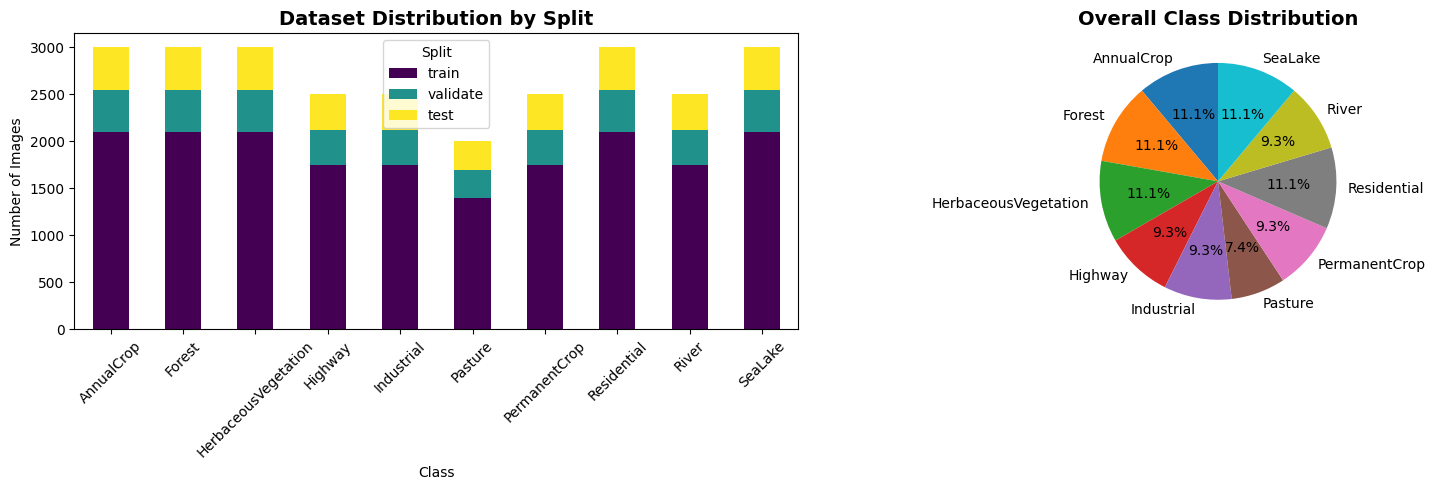


Dataset Statistics:
                      train  validate  test
AnnualCrop             2100       450   450
Forest                 2100       450   450
HerbaceousVegetation   2100       450   450
Highway                1750       375   375
Industrial             1750       375   375
Pasture                1400       300   300
PermanentCrop          1750       375   375
Residential            2100       450   450
River                  1750       375   375
SeaLake                2100       450   450

Total images: 27000


In [55]:
def plot_dataset_distribution(dataset_root):
    splits = ['train', 'validate', 'test']
    class_counts = defaultdict(lambda: defaultdict(int))
    
    for split in splits:
        split_path = dataset_root / split
        if not split_path.exists():
            continue
        for class_name in os.listdir(split_path):
            class_path = split_path / class_name
            if class_path.is_dir():
                count = len([f for f in os.listdir(class_path) 
                           if f.lower().endswith(('.jpg', '.png', '.tif'))])
                class_counts[class_name][split] = count
    
    df = pd.DataFrame(class_counts).T
    df = df[splits] 
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    df.plot(kind='bar', stacked=True, ax=ax1, colormap='viridis')
    ax1.set_title('Dataset Distribution by Split', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Class')
    ax1.set_ylabel('Number of Images')
    ax1.legend(title='Split')
    ax1.tick_params(axis='x', rotation=45)
    
    totals = df.sum(axis=1)
    ax2.pie(totals, labels=totals.index, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return df

distribution_df = plot_dataset_distribution(config['dataset_root'])
print("\nDataset Statistics:")
print(distribution_df)
print(f"\nTotal images: {distribution_df.sum().sum()}")

## 2. Sample Images Grid with Predictions

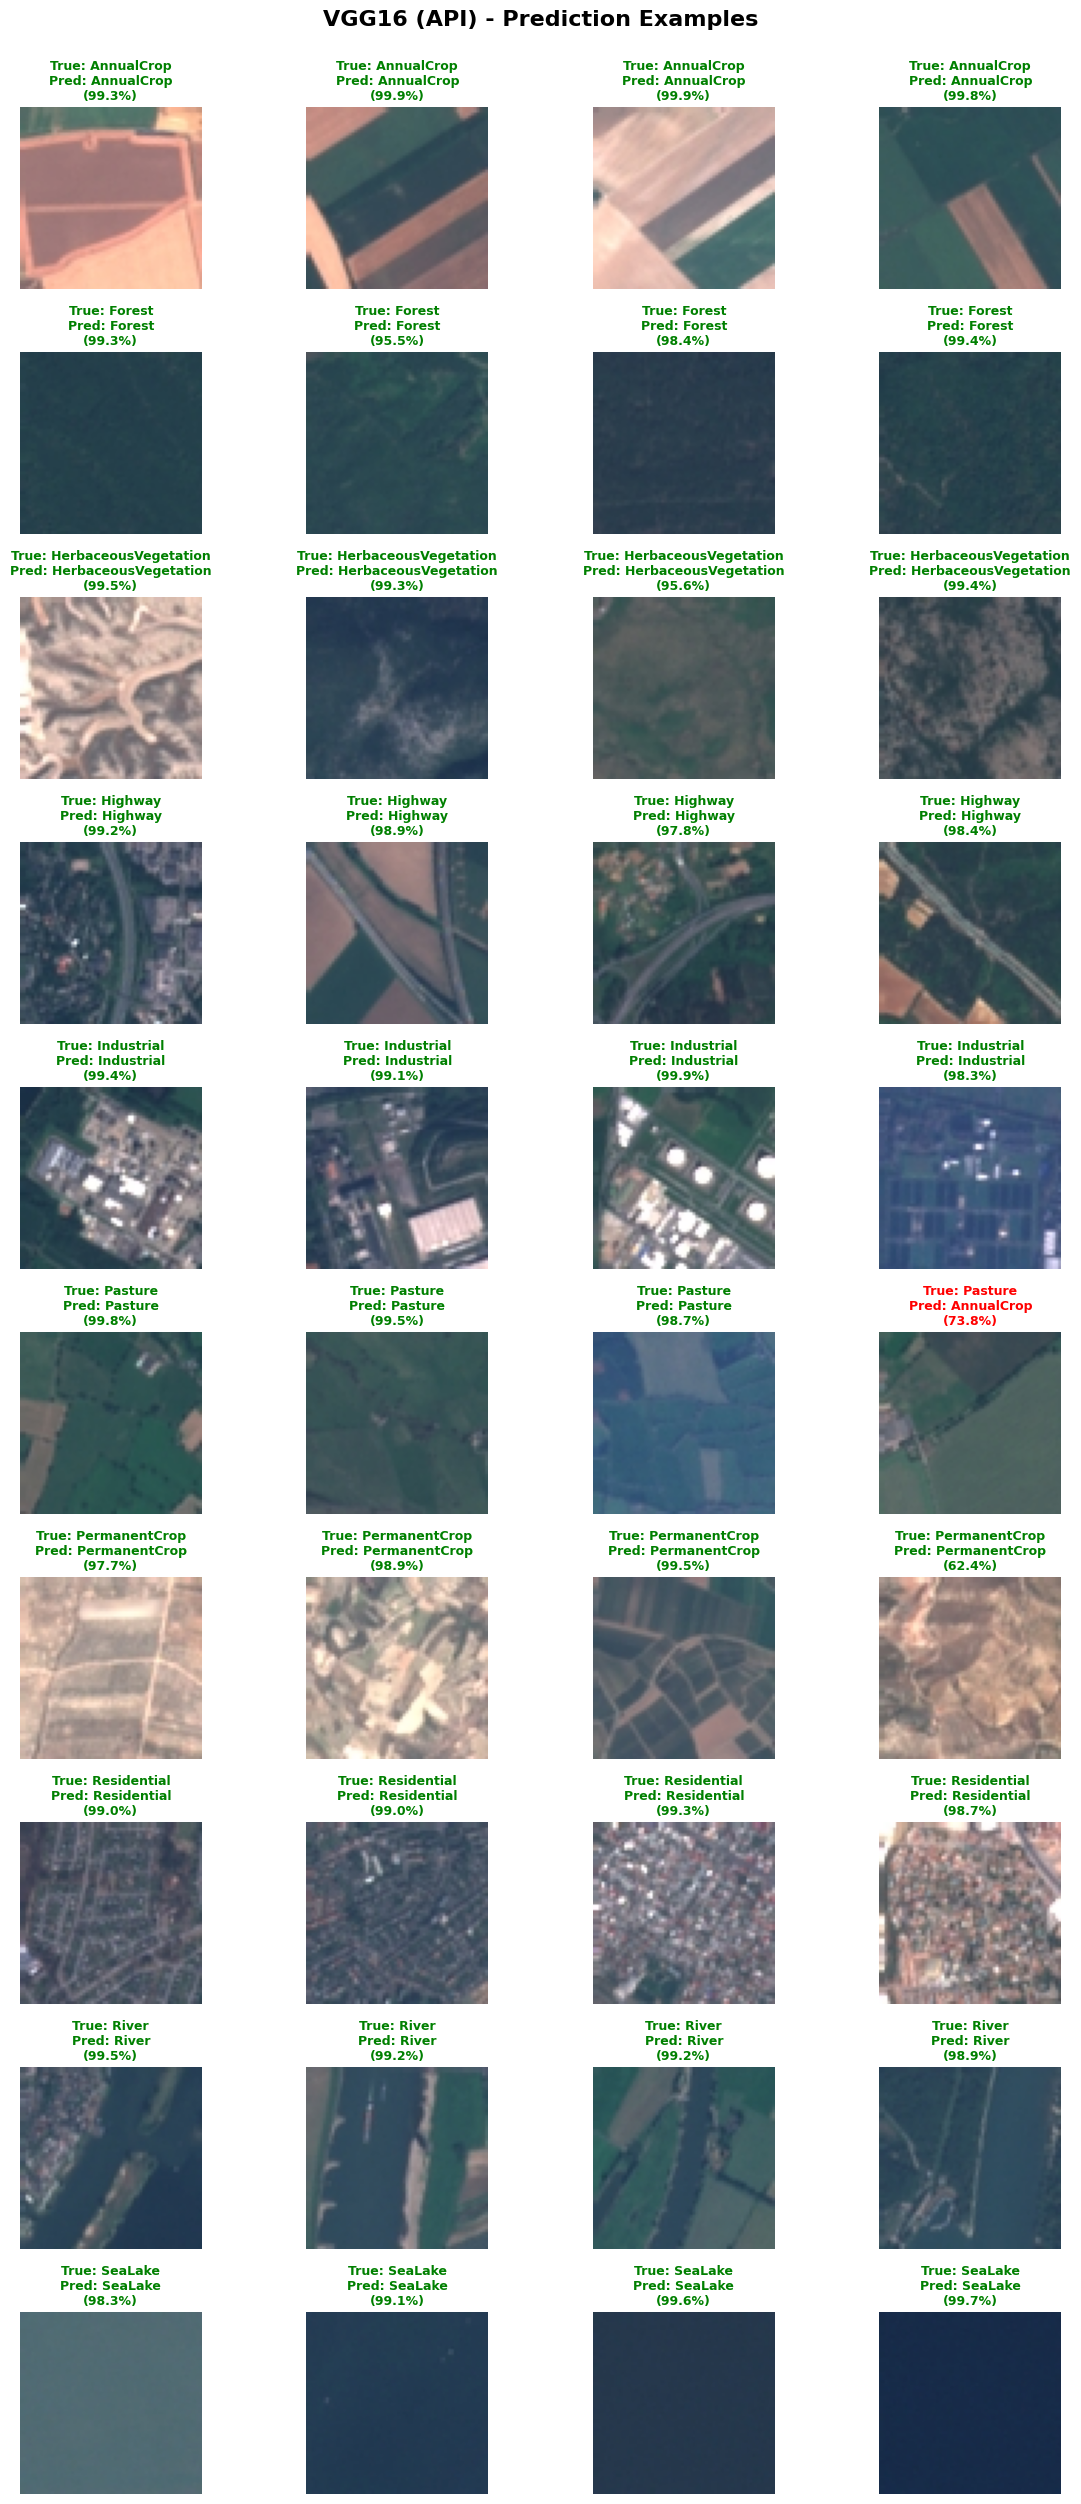

In [56]:
def plot_predictions_grid(model, dataset_root, class_names, img_size, samples_per_class=3):
    config['img_size'] = model.input_shape[1:3]

    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, samples_per_class, 
                            figsize=(samples_per_class*3, n_classes*2.5))
    
    if n_classes == 1:
        axes = axes.reshape(1, -1)
    
    for idx, class_name in enumerate(class_names):
        class_path = dataset_root / 'test' / class_name
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.jpg', '.png', '.tif'))]
        
        selected = random.sample(images, min(samples_per_class, len(images)))
        
        for i, img_name in enumerate(selected):
            img_path = class_path / img_name
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Prepare for prediction
            img_resized = cv2.resize(img_rgb, img_size)
            img_array = np.expand_dims(img_resized, axis=0) / 255.0
            # img_array = preprocess_input(img_array)
            
            # Predict
            pred = model.predict(img_array, verbose=0)
            pred_class_idx = np.argmax(pred)
            pred_class = class_names[pred_class_idx]
            confidence = pred[0][pred_class_idx] * 100
            
            # Plot
            ax = axes[idx, i] if n_classes > 1 else axes[i]
            ax.imshow(img_rgb)
            
            # Color code: green if correct, red if wrong
            color = 'green' if pred_class == class_name else 'red'
            ax.set_title(f'True: {class_name}\nPred: {pred_class}\n({confidence:.1f}%)',
                        fontsize=9, color=color, fontweight='bold')
            ax.axis('off')
    
    plt.suptitle(f'{config["model_name"]} - Prediction Examples', 
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

plot_predictions_grid(model, config['dataset_root'], class_names, 
                     config['img_size'], samples_per_class=4)

## 3. Detailed Confusion Matrix with Statistics

Generating predictions...


c:\Users\S1NdBAD\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


127/127 ━━━━━━━━━━━━━━━━━━━━ 53s 419ms/step


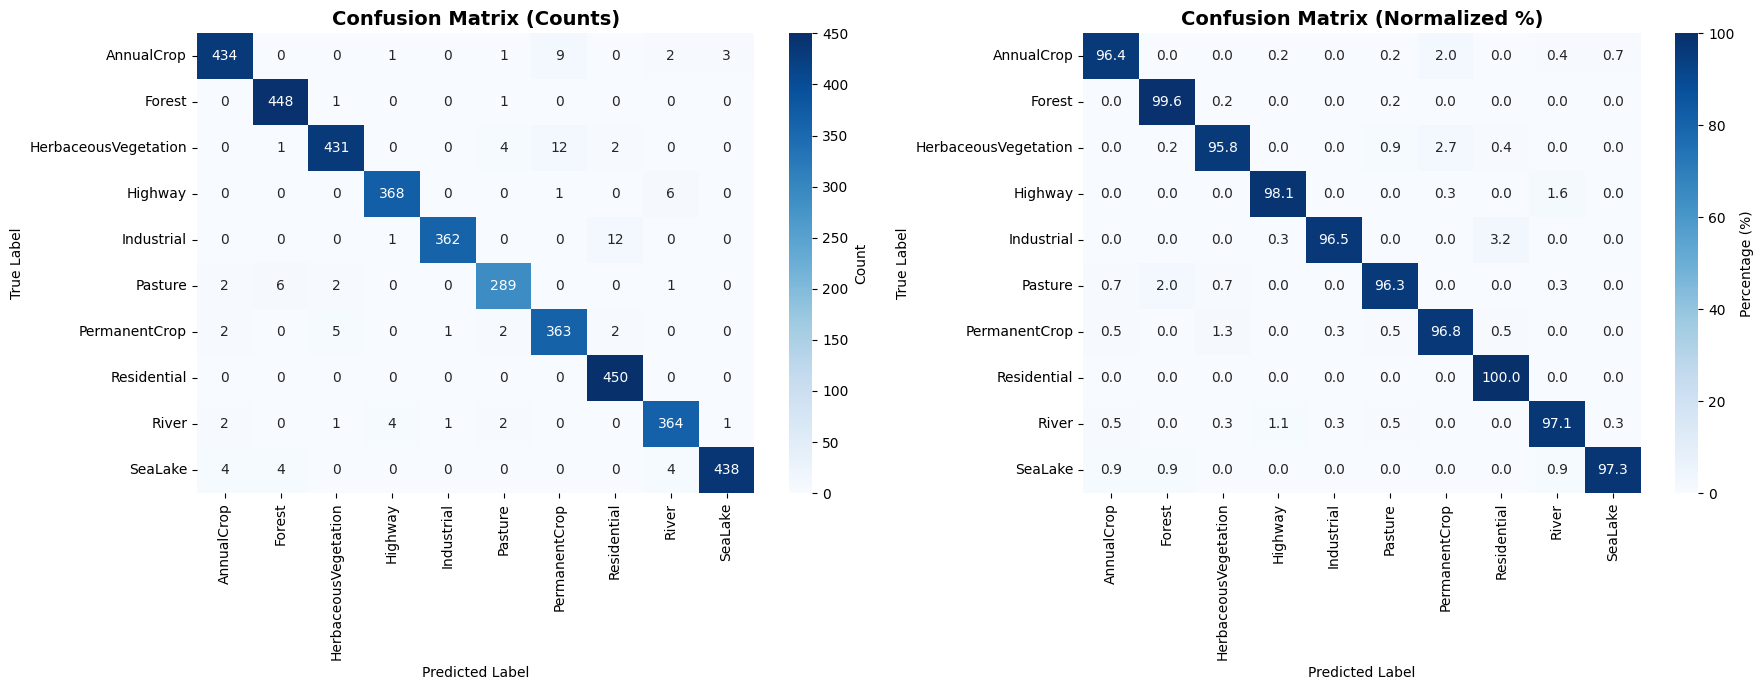


DETAILED CLASSIFICATION REPORT
                      precision    recall  f1-score   support

          AnnualCrop     0.9775    0.9644    0.9709       450
              Forest     0.9760    0.9956    0.9857       450
HerbaceousVegetation     0.9795    0.9578    0.9685       450
             Highway     0.9840    0.9813    0.9826       375
          Industrial     0.9945    0.9653    0.9797       375
             Pasture     0.9666    0.9633    0.9649       300
       PermanentCrop     0.9429    0.9680    0.9553       375
         Residential     0.9657    1.0000    0.9825       450
               River     0.9655    0.9707    0.9681       375
             SeaLake     0.9910    0.9733    0.9821       450

            accuracy                         0.9746      4050
           macro avg     0.9743    0.9740    0.9740      4050
        weighted avg     0.9748    0.9746    0.9746      4050



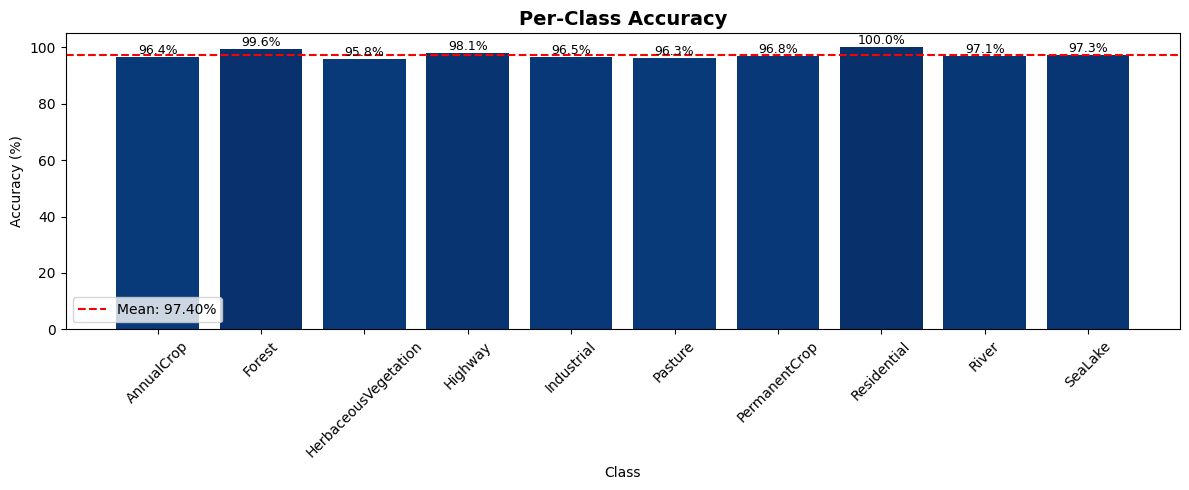

In [57]:
def plot_enhanced_confusion_matrix(model, test_generator, class_names):
    print("Generating predictions...")
    predictions = model.predict(test_generator, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_generator.classes
    
    cm = confusion_matrix(y_true, y_pred)
    
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=ax1, cbar_kws={'label': 'Count'})
    ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # Percentages
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax2, cbar_kws={'label': 'Percentage (%)'})
    ax2.set_title('Confusion Matrix (Normalized %)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('True Label')
    ax2.set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*70)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
    
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(class_names, per_class_acc, color=plt.cm.Blues(per_class_acc/100)) #type:ignore
    ax.axhline(y=per_class_acc.mean(), color='red', linestyle='--', 
              label=f'Mean: {per_class_acc.mean():.2f}%')
    ax.set_xlabel('Class')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return cm, y_pred, y_true

cm, y_pred, y_true = plot_enhanced_confusion_matrix(model, test_generator, class_names)

## 4. Misclassification Analysis

Top Misclassification Pairs:
  True -> Predicted
  HerbaceousVegetation -> PermanentCrop: 12 times
  Industrial -> Residential: 12 times
  AnnualCrop -> PermanentCrop: 9 times
  Highway -> River: 6 times
  Pasture -> Forest: 6 times

Showing examples: HerbaceousVegetation misclassified as PermanentCrop


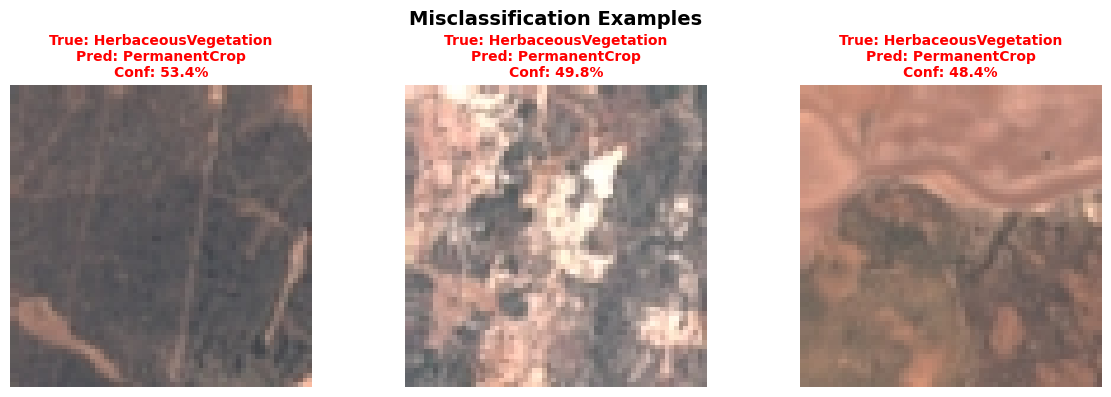

In [58]:
def plot_misclassification_analysis(model, dataset_root, class_names, img_size, y_pred, y_true):
    misclassified_mask = y_pred != y_true
    misclassified_true = y_true[misclassified_mask]
    misclassified_pred = y_pred[misclassified_mask]
    
    misc_pairs = defaultdict(int)
    for true_idx, pred_idx in zip(misclassified_true, misclassified_pred):
        pair = (class_names[true_idx], class_names[pred_idx])
        misc_pairs[pair] += 1
    
    top_pairs = sorted(misc_pairs.items(), key=lambda x: x[1], reverse=True)[:5]
    
    print("Top Misclassification Pairs:")
    print("  True -> Predicted")
    for (true_class, pred_class), count in top_pairs:
        print(f"  {true_class} -> {pred_class}: {count} times")
    
    if top_pairs:
        true_class, pred_class = top_pairs[0][0]
        print(f"\nShowing examples: {true_class} misclassified as {pred_class}")
        
        test_path = dataset_root / 'test' / true_class
        images = list(test_path.glob('*.jpg')) + list(test_path.glob('*.png')) + list(test_path.glob('*.tif'))
        
        examples_found = []
        for img_path in images:
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, img_size)
            img_array = np.expand_dims(img_resized, axis=0) / 255.0
            # img_array = preprocess_input(img_array)
            
            pred = model.predict(img_array, verbose=0)
            pred_idx = np.argmax(pred)
            
            if class_names[pred_idx] == pred_class:
                examples_found.append((img_rgb, pred[0][pred_idx]))
                if len(examples_found) >= 4:
                    break
        
        if examples_found:
            fig, axes = plt.subplots(1, len(examples_found), figsize=(4*len(examples_found), 4))
            if len(examples_found) == 1:
                axes = [axes]
            
            for ax, (img, conf) in zip(axes, examples_found):
                ax.imshow(img)
                ax.set_title(f'True: {true_class}\nPred: {pred_class}\nConf: {conf*100:.1f}%',
                           fontsize=10, color='red', fontweight='bold')
                ax.axis('off')
            
            plt.suptitle('Misclassification Examples', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

plot_misclassification_analysis(model, config['dataset_root'], 
                               class_names, config['img_size'], y_pred, y_true)

## 5. Model Architecture Summary

In [59]:
def visualize_model_summary(model):
    print("="*70)
    print(f"MODEL ARCHITECTURE: {config['model_name']}")
    print("="*70)
    model.summary()
    
    layer_types = defaultdict(lambda: {'params': 0, 'count': 0})
    for layer in model.layers:
        layer_type = layer.__class__.__name__
        layer_types[layer_type]['params'] += layer.count_params()
        layer_types[layer_type]['count'] += 1
    
    print("\n" + "="*70)
    print("PARAMETERS BY LAYER TYPE")
    print("="*70)
    print(f"{'Layer Type':<20} {'Count':<10} {'Parameters':<15} {'% of Total'}")
    print("-"*70)
    
    total_params = sum(layer.count_params() for layer in model.layers)
    for layer_type, info in sorted(layer_types.items(), key=lambda x: x[1]['params'], reverse=True):
        pct = info['params'] / total_params * 100
        print(f"{layer_type:<20} {info['count']:<10} {info['params']:<15,} {pct:>6.2f}%")

visualize_model_summary(model)

MODEL ARCHITECTURE: VGG16 (API)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,610 (56.65 MB)

 Trainable params: 14,849,098 (56.64 MB)

 Non-trainable params: 512 (2.00 KB)


PARAMETERS BY LAYER TYPE
Layer Type           Count      Parameters      % of Total
----------------------------------------------------------------------
Functional           1          14,714,688       99.09%
Dense                2          133,898           0.90%
BatchNormalization   1          1,024             0.01%
GlobalAveragePooling2D 1          0                 0.00%
Dropout              1          0                 0.00%
